# Carga y vista general

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

df = pd.read_csv("../data/mall_customers.csv",
                 names=["CustomerID", "Gender", "Age", "AnnualIncome", "SpendingScore"],
                 header=0)

print(f"Dimensiones: {df.shape}")
print(f"\nTipos de datos:\n{df.dtypes}")
print(f"\nValores nulos:\n{df.isnull().sum()}")
df.describe().round(2)

Dimensiones: (200, 5)

Tipos de datos:
CustomerID       int64
Gender             str
Age              int64
AnnualIncome     int64
SpendingScore    int64
dtype: object

Valores nulos:
CustomerID       0
Gender           0
Age              0
AnnualIncome     0
SpendingScore    0
dtype: int64


,CustomerID,Age,AnnualIncome,SpendingScore
count,200.00,200.00,200.00,200.00
mean,100.50,38.85,60.56,50.20
std,57.88,13.97,26.26,25.82
min,1.00,18.00,15.00,1.00
25%,50.75,28.75,41.50,34.75
50%,100.50,36.00,61.50,50.00
75%,150.25,49.00,78.00,73.00
max,200.00,70.00,137.00,99.00


#  Distribucion de variables numericas

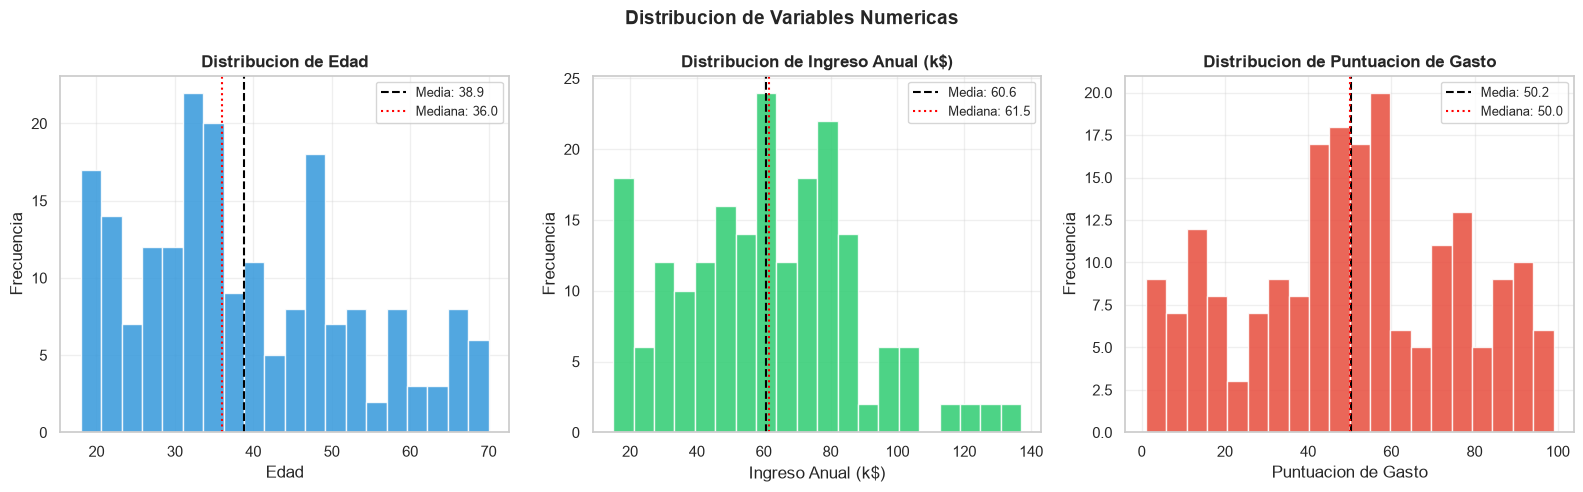

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, color, title in zip(
    axes,
    ["Age", "AnnualIncome", "SpendingScore"],
    ["#3498db", "#2ecc71", "#e74c3c"],
    ["Edad", "Ingreso Anual (k$)", "Puntuacion de Gasto"]
):
    ax.hist(df[col], bins=20, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(df[col].mean(), color="black", linestyle="--",
               label=f"Media: {df[col].mean():.1f}")
    ax.axvline(df[col].median(), color="red", linestyle=":",
               label=f"Mediana: {df[col].median():.1f}")
    ax.set_title(f"Distribucion de {title}", fontweight="bold")
    ax.set_xlabel(title)
    ax.set_ylabel("Frecuencia")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("Distribucion de Variables Numericas", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/eda_01_distribuciones.png", dpi=150, bbox_inches="tight")
plt.show()

- Edad: distribucion sesgada a la derecha, mayoria entre 20-40 años.
- Ingreso: distribucion aproximadamente uniforme entre 15k y 137k dolares.
- Gasto: distribucion bimodal con picos en valores bajos y altos — sugiere segmentos extremos.

# Genero

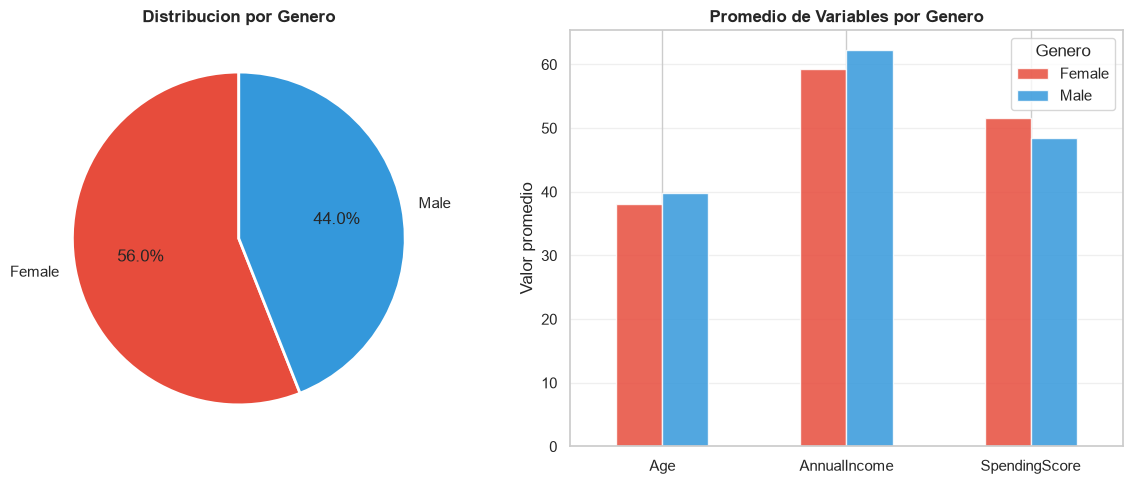

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df["Gender"].value_counts()
axes[0].pie(counts, labels=counts.index, autopct="%1.1f%%",
            colors=["#e74c3c", "#3498db"],
            wedgeprops={"edgecolor": "white", "linewidth": 2},
            startangle=90)
axes[0].set_title("Distribucion por Genero", fontweight="bold")

df.groupby("Gender")[["Age", "AnnualIncome", "SpendingScore"]].mean().T.plot(
    kind="bar", ax=axes[1], color=["#e74c3c", "#3498db"],
    edgecolor="white", alpha=0.85
)
axes[1].set_title("Promedio de Variables por Genero", fontweight="bold")
axes[1].set_ylabel("Valor promedio")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Genero")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/eda_02_genero.png", dpi=150, bbox_inches="tight")
plt.show()

- El 56% de los clientes son mujeres.
- Las mujeres tienen una puntuacion de gasto ligeramente mayor que los hombres.
- El ingreso promedio es similar entre generos — el gasto no depende del ingreso.

# Correlaciones

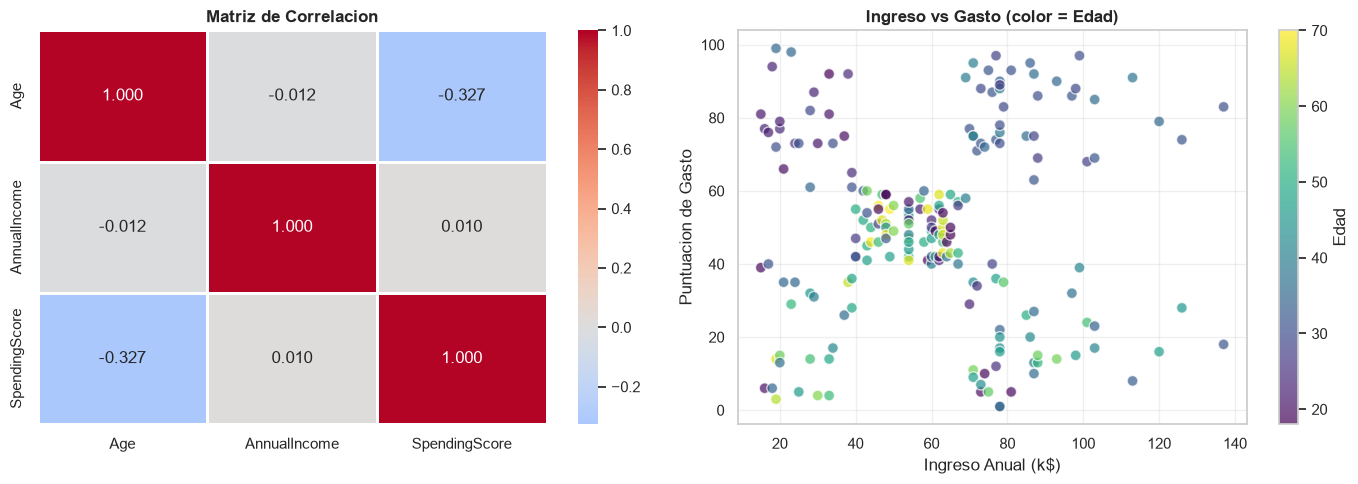

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

corr = df[["Age", "AnnualIncome", "SpendingScore"]].corr()
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", center=0,
            ax=axes[0], linewidths=1, annot_kws={"size": 12})
axes[0].set_title("Matriz de Correlacion", fontweight="bold")

axes[1].scatter(df["AnnualIncome"], df["SpendingScore"],
                c=df["Age"], cmap="viridis", alpha=0.7, s=60, edgecolors="white")
cb = plt.colorbar(axes[1].collections[0], ax=axes[1])
cb.set_label("Edad")
axes[1].set_xlabel("Ingreso Anual (k$)")
axes[1].set_ylabel("Puntuacion de Gasto")
axes[1].set_title("Ingreso vs Gasto (color = Edad)", fontweight="bold")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/eda_03_correlaciones.png", dpi=150, bbox_inches="tight")
plt.show()

- Correlacion negativa moderada entre Edad y Puntuacion de Gasto (-0.33):
  los clientes mayores tienden a gastar menos.
- Correlacion practicamente nula entre Ingreso y Gasto (0.01):
  el ingreso NO predice el comportamiento de gasto — hallazgo clave para clustering.
- Esto justifica usar las tres variables como features independientes en los modelos.

#  Scatter matrix y boxplots

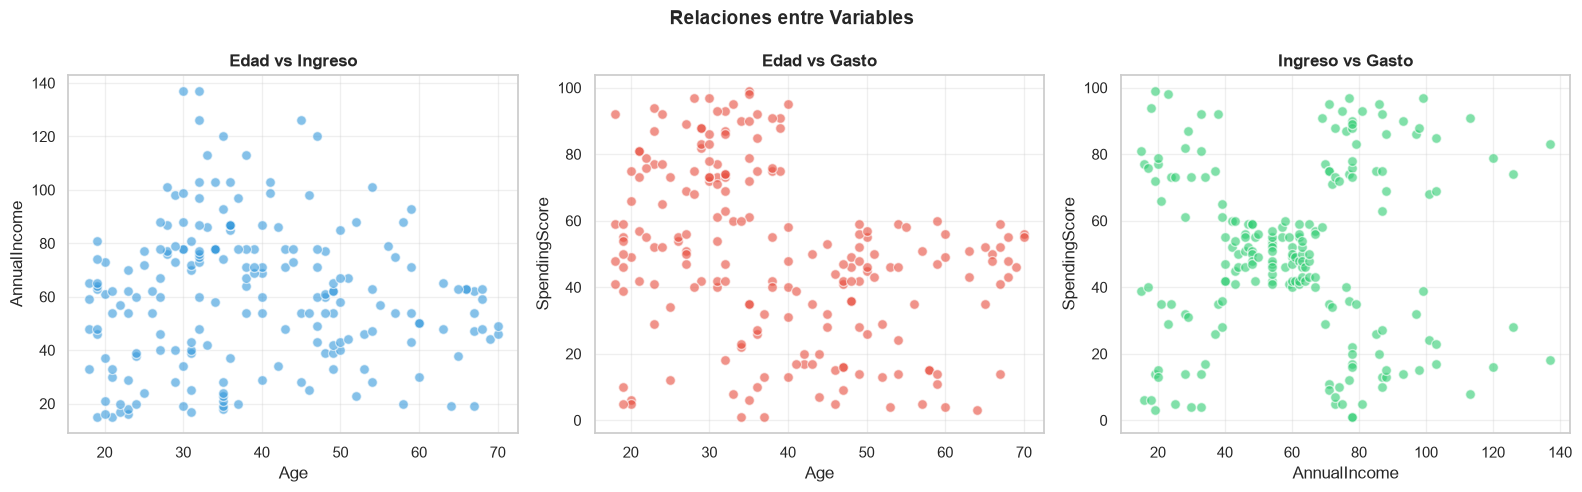

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pairs = [("Age", "AnnualIncome"), ("Age", "SpendingScore"), ("AnnualIncome", "SpendingScore")]
titles = ["Edad vs Ingreso", "Edad vs Gasto", "Ingreso vs Gasto"]
colors = ["#3498db", "#e74c3c", "#2ecc71"]

for ax, (x, y), title, color in zip(axes, pairs, titles, colors):
    ax.scatter(df[x], df[y], color=color, alpha=0.6, s=50, edgecolors="white")
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(title, fontweight="bold")
    ax.grid(alpha=0.3)

plt.suptitle("Relaciones entre Variables", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/eda_04_scatter_pairs.png", dpi=150, bbox_inches="tight")
plt.show()

# Outliers

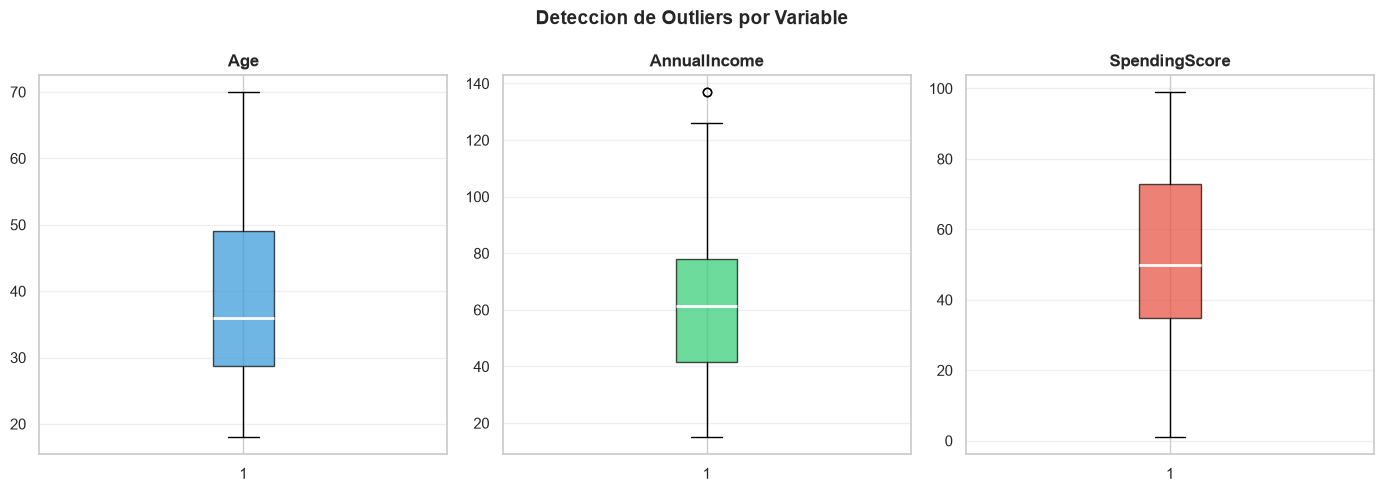

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col, color in zip(
    axes,
    ["Age", "AnnualIncome", "SpendingScore"],
    ["#3498db", "#2ecc71", "#e74c3c"]
):
    bp = ax.boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.7),
                    medianprops=dict(color="white", linewidth=2))
    ax.set_title(col, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Deteccion de Outliers por Variable", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/eda_05_outliers.png", dpi=150, bbox_inches="tight")
plt.show()

1. No hay valores nulos — dataset limpio.
2. No hay outliers severos que requieran eliminacion.
3. Escalar las features es obligatorio (rangos muy distintos: Age 18-70, Income 15-137).
4. La baja correlacion entre variables las hace complementarias para clustering.
5. La distribucion bimodal del gasto anticipa la existencia de segmentos extremos.
6. Se recomienda K-Means con K=5 o K=6 como punto de partida.